# 04 · Which funnel stage to invest in? — mediation (pathmc)

**The decision.** We have a fixed budget to split across the funnel —
**onboarding → engagement → activation → conversion**. Which stage gives the most
leverage on paid conversion, *respecting that effects cascade*? A dollar into
onboarding doesn't just help onboarding; it flows downstream through engagement and
activation. We need to trace those paths, not just correlate each stage with revenue.

`pathmc` builds the chain as a structural causal model and computes **path-specific
effects** by propagating posterior draws through the intervened graph — the modern,
uncertainty-aware version of mediation analysis.

7-step contract, with the mediation decomposition as the star.


In [1]:
import os, warnings, numpy as np, pandas as pd, matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
import pathmc
from cmp import dgp, plots
plots.use_style()
FAST = os.environ.get("CMP_FAST", "1") == "1"
FIT = dict(draws=400, tune=400, chains=2) if FAST else dict(draws=1500, tune=1500, chains=4)
SEED = 13

## 2 · Simulate a ground truth

A chain: `onboarding_score → engagement → activated → converted`, with
`channel_quality` feeding engagement and activation. The planted structure gives a
known **total** effect of onboarding on conversion, split into paths — most of it
flows through `engagement → activated`, a little through `engagement → converted`
directly.


In [2]:
df, true_effects = dgp.funnel(n=1000, seed=SEED)
print("TRUE effects of onboarding on conversion:")
for k, v in true_effects.items():
    print(f"  {k:36s} {v:.2f}")
df.head()

TRUE effects of onboarding on conversion:
  indirect_via_engagement_activated    3.17
  indirect_via_engagement_only         0.77
  total                                3.94


,onboarding_score,channel_quality,engagement,activated,converted
0,0.864798,0.726815,2.576471,3.869429,4.870321
1,0.855303,0.790067,3.206651,5.673260,6.371102
2,0.811023,0.348493,2.493785,4.691864,5.394113
3,0.261446,0.465793,0.572682,1.261547,1.264003
4,0.077199,0.887974,1.520775,3.259916,3.146544


## 3 · Identify — direct vs indirect effects

For a chain $X\to M\to Y$, the **total effect** decomposes into a **natural direct
effect** and **natural indirect effect** (Pearl):

$$\text{TE} = \text{NDE} + \text{NIE},\qquad
\text{NDE}=\mathbb{E}[Y(1,M(0))-Y(0,M(0))],\quad
\text{NIE}=\mathbb{E}[Y(1,M(1))-Y(1,M(0))].$$

Under a linear SCM these are the classic **product-of-coefficients**: for
$M=aX+\dots,\ Y=bM+cX+\dots$, the indirect effect is $a\cdot b$ and the direct is
$c$. `pathmc` computes path-specific effects for nonlinear chains too, by simulating
through the intervened graph.

**Assumptions (stronger than a single-link analysis):** no unmeasured confounding of
$X\!-\!Y$, $M\!-\!Y$, *and* $X\!-\!M$; plus the **cross-world** condition that no
$M\!-\!Y$ confounder is itself affected by $X$. Natural effects are *not identified*
if that last one fails — worth flagging to stakeholders.


## 4 · Estimate — fit the chain and query paths

In [3]:
spec = '''
engagement ~ e_on*onboarding_score + e_ch*channel_quality
activated  ~ a_eng*engagement + a_ch*channel_quality
converted  ~ c_act*activated + c_eng*engagement
'''
m = pathmc.model(spec, data=df)
idata = m.fit(random_seed=SEED, progressbar=False, **FIT)
m.effects_summary().round(3)

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (2 chains in 2 jobs)


NUTS: [sigma_engagement, beta_engagement, beta_converted, sigma_activated, beta_activated, sigma_converted]


Sampling 2 chains for 400 tune and 400 draw iterations (800 + 800 draws total) took 2 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


,mean,sd,hdi_3%,hdi_97%
name,,,,
e_on,2.150,0.042,2.073,2.226
e_ch,1.131,0.043,1.043,1.207
a_eng,1.616,0.018,1.584,1.652
a_ch,0.592,0.054,0.490,0.690
c_act,0.896,0.022,0.857,0.940
c_eng,0.361,0.040,0.286,0.430


## 5 · Validate — recover the total and the paths

In [4]:
# draws() gives the posterior sample array for both ATE and path-effect results;
# we compute mean/CI ourselves so the interface is uniform.
def get_draws(res):
    # pathmc EstimandResult.draws is a method; EffectResult.draws is an ndarray attr
    d = res.draws
    return np.asarray(d() if callable(d) else d)

def summarise(res, label, truth):
    d = get_draws(res)
    lo, hi = np.quantile(d, [0.05, 0.95])
    print(f"{label:34s} mean {d.mean():5.2f}  (true {truth:.2f})   [90% {lo:.2f}, {hi:.2f}]")
    return d

total_d = summarise(m.ate("converted", "onboarding_score"), "TOTAL onboarding → converted", true_effects['total'])
via_act = summarise(m.effect("onboarding_score -> engagement -> activated -> converted"),
                    "  via engagement→activated→conv", true_effects['indirect_via_engagement_activated'])
via_eng = summarise(m.effect("onboarding_score -> engagement -> converted"),
                    "  via engagement→converted", true_effects['indirect_via_engagement_only'])

TOTAL onboarding → converted       mean  3.89  (true 3.94)   [90% 3.74, 4.04]
  via engagement→activated→conv    mean  3.11  (true 3.17)   [90% 2.95, 3.28]
  via engagement→converted         mean  0.78  (true 0.77)   [90% 0.63, 0.92]


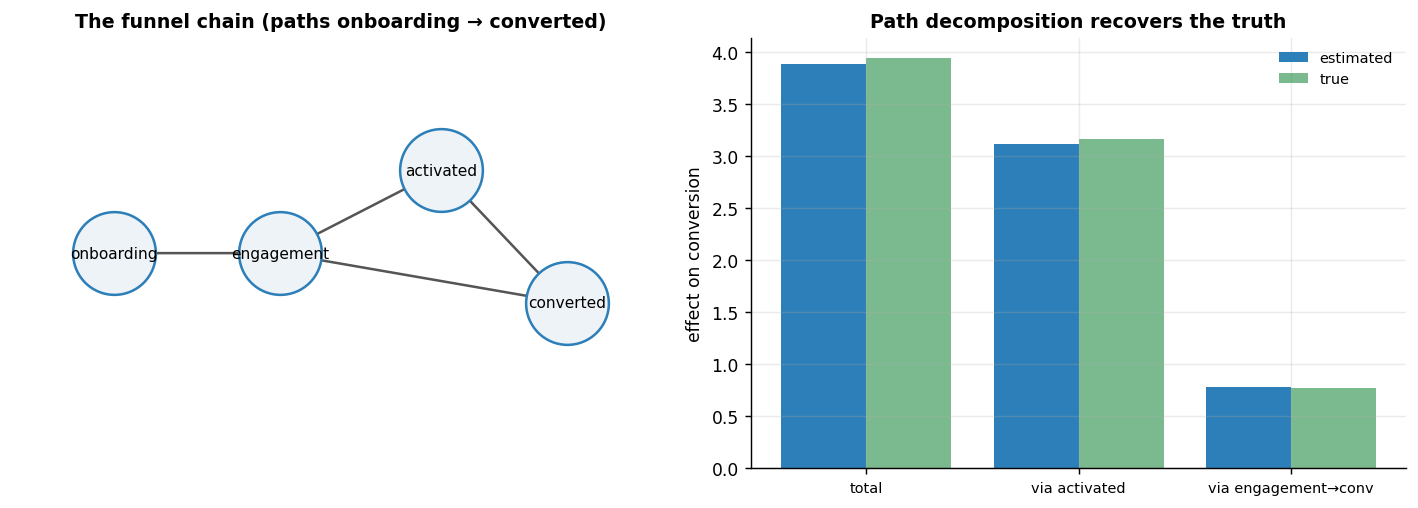

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
# path diagram
pos = {"onboarding": (0.05, 0.5), "engagement": (0.38, 0.5), "activated": (0.7, 0.75), "converted": (0.95, 0.35)}
edges = [("onboarding","engagement"),("engagement","activated"),("activated","converted"),("engagement","converted")]
plots.draw_dag(ax[0], pos, edges, title="The funnel chain (paths onboarding → converted)")
# effect decomposition bars
labels = ["total", "via activated", "via engagement→conv"]
means = [total_d.mean(), via_act.mean(), via_eng.mean()]
truths = [true_effects['total'], true_effects['indirect_via_engagement_activated'], true_effects['indirect_via_engagement_only']]
x = np.arange(len(labels))
ax[1].bar(x-0.2, means, 0.4, color=plots.BLUE, label="estimated")
ax[1].bar(x+0.2, truths, 0.4, color=plots.GREEN, alpha=0.6, label="true")
ax[1].set_xticks(x); ax[1].set_xticklabels(labels, fontsize=8); ax[1].legend(frameon=False, fontsize=8)
ax[1].set_ylabel("effect on conversion"); ax[1].set_title("Path decomposition recovers the truth")
fig.tight_layout()

## 6 · Decide, in euros — where does the marginal euro go?

The funnel-investment question is **which stage's input has the most conversion
leverage**. We value a **+1-unit improvement** in each stage's input at
€/conversion, using the *total* downstream effect (onboarding's leverage includes
everything it triggers downstream — that's the whole point of tracing paths). We
rank stages, and flag the close/uncertain calls as **experiments, not blind bets**.


In [6]:
VALUE_PER_CONVERSION = 120.0   # € value of one conversion
# value of a +1-unit improvement in each stage's input (total downstream effect × value)
levers = {
    "onboarding_score": total_d,                                    # total effect (cascades)
    "engagement":       get_draws(m.ate("converted", "engagement")),
    "activated":        get_draws(m.ate("converted", "activated")),
}
rows = []
for stage, d in levers.items():
    val = d * VALUE_PER_CONVERSION
    rows.append({"lever": stage, "€/unit input": round(val.mean(), 0),
                 "90% CI": f"[{np.quantile(val,0.05):.0f}, {np.quantile(val,0.95):.0f}]"})
tbl = pd.DataFrame(rows).sort_values("€/unit input", ascending=False)
best = tbl.iloc[0]["lever"]
print(f"Highest-leverage lever: {best}  (€{tbl.iloc[0]['€/unit input']:.0f} of conversion value per unit)")
print("Onboarding's leverage cascades through the whole funnel — that's why tracing")
print("paths beats crediting each stage by its raw correlation with conversion.\n")
tbl.reset_index(drop=True)

Highest-leverage lever: onboarding_score  (€467 of conversion value per unit)
Onboarding's leverage cascades through the whole funnel — that's why tracing
paths beats crediting each stage by its raw correlation with conversion.



,lever,€/unit input,90% CI
0,onboarding_score,467.0,"[449, 485]"
1,engagement,217.0,"[213, 221]"
2,activated,107.0,"[103, 112]"


## 7 · Caveats

- **Natural effects lean on strong assumptions** — no unmeasured confounding of any
  of the three links, plus the cross-world condition. If an unmeasured trait drives
  both engagement and conversion, the split is biased even if the total is fine.
- **Don't control away the mechanism.** The whole point is to *decompose* the path;
  adjusting for a mediator when you wanted the total effect would remove the very
  thing you're pricing (see notebook 05).
- **Linear-SCM decomposition is exact only if the SCM is linear.** For strong
  nonlinearities/interactions, lean on `pathmc`'s simulate-through-the-graph numbers
  rather than hand-multiplied coefficients.
